In [7]:
import numpy as np

# Define the Chebyshev points for n = 3
n = 3
chebyshev_points = [np.cos((2*k + 1) * np.pi / (2 * n + 2)) for k in range(n + 1)]

# Define the function f(x)
def f(x):
    return 1 if x >= 0 else -1

# Evaluate f(x) at the Chebyshev points
function_values = [f(x) for x in chebyshev_points]

chebyshev_points, function_values


([0.9238795325112867,
  0.38268343236508984,
  -0.3826834323650897,
  -0.9238795325112867],
 [1, 1, -1, -1])

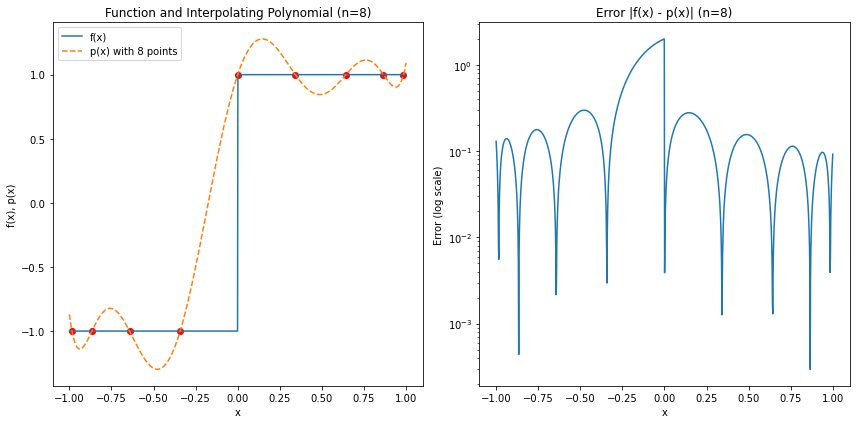

In [8]:
import matplotlib.pyplot as plt

def chebyshev_points(n):
    """ Generate Chebyshev points for a given n. """
    return [np.cos((2*k + 1) * np.pi / (2 * n + 2)) for k in range(n + 1)]

def barycentric_interpolate(x, x_points, y_points):
    """ Evaluate the interpolating polynomial at x using Barycentric formula. """
    n = len(x_points)
    weights = np.ones(n)
    for j in range(n):
        for k in range(n):
            if j != k:
                weights[j] /= (x_points[j] - x_points[k])

    numerator = 0
    denominator = 0
    for j in range(n):
        term = weights[j] / (x - x_points[j])
        numerator += y_points[j] * term
        denominator += term
    
    return numerator / denominator

# Function to evaluate and plot the function, its approximation, and the error
def plot_approximation_and_error(n_points):
    # Generate Chebyshev points and function values
    x_points = chebyshev_points(n_points)
    y_points = [f(x) for x in x_points]

    # Define the range for plotting
    x_range = np.linspace(-1, 1, 1000)
    f_values = np.array([f(x) for x in x_range])
    p_values = np.array([barycentric_interpolate(x, x_points, y_points) for x in x_range])
    error = np.abs(f_values - p_values)

    # Plotting the function and the polynomial
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(x_range, f_values, label='f(x)')
    plt.plot(x_range, p_values, label=f'p(x) with {n_points} points', linestyle='--')
    plt.scatter(x_points, y_points, color='red')  # Interpolation points
    plt.title(f"Function and Interpolating Polynomial (n={n_points})")
    plt.xlabel("x")
    plt.ylabel("f(x), p(x)")
    plt.legend()

    # Plotting the error
    plt.subplot(1, 2, 2)
    plt.plot(x_range, error)
    plt.yscale('log')
    plt.title(f"Error |f(x) - p(x)| (n={n_points})")
    plt.xlabel("x")
    plt.ylabel("Error (log scale)")

    plt.tight_layout()
    plt.show()

# Plot for 8 points
plot_approximation_and_error(8)


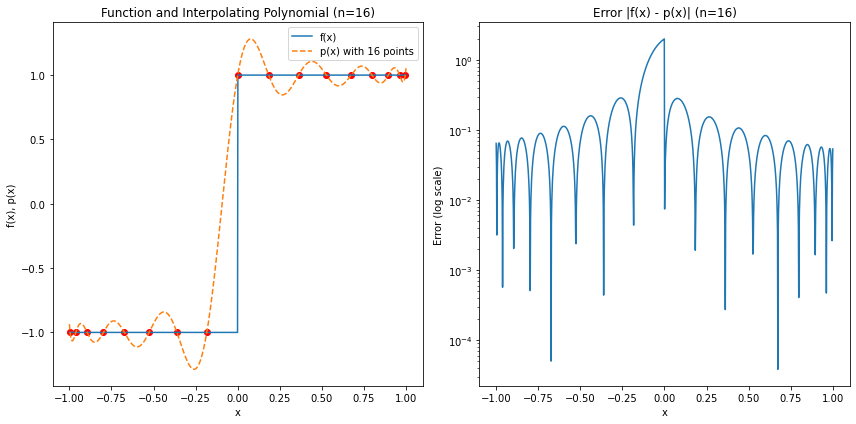

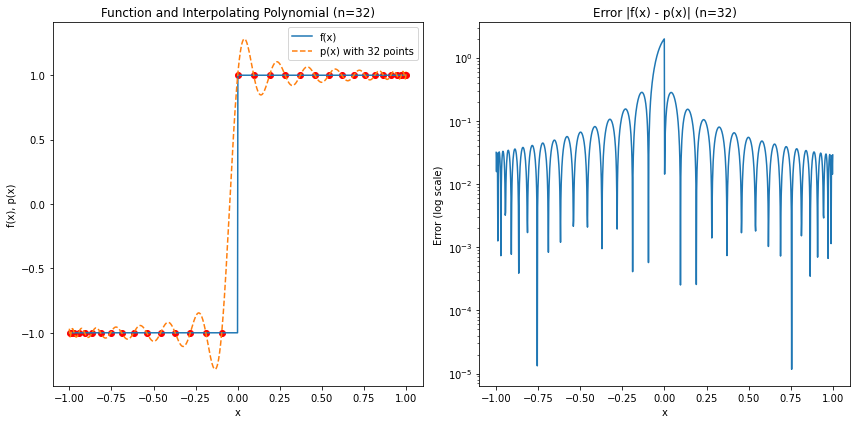

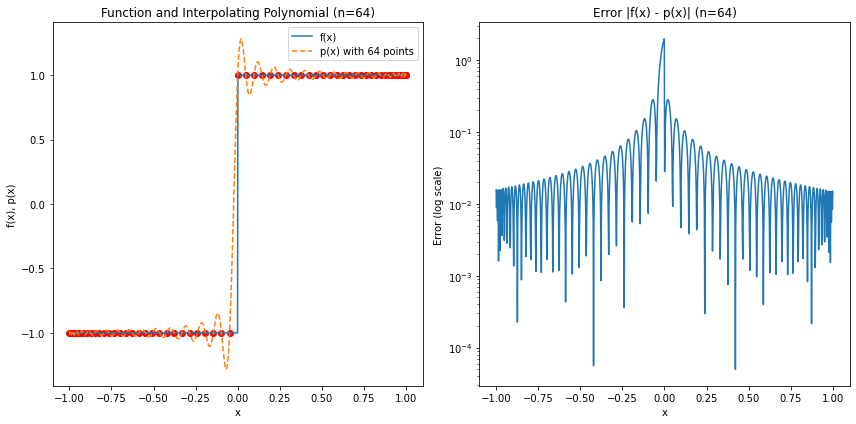

In [11]:
# Plot for different numbers of points: 16, 32, 64
for n_points in [16, 32, 64]:
    plot_approximation_and_error(n_points)


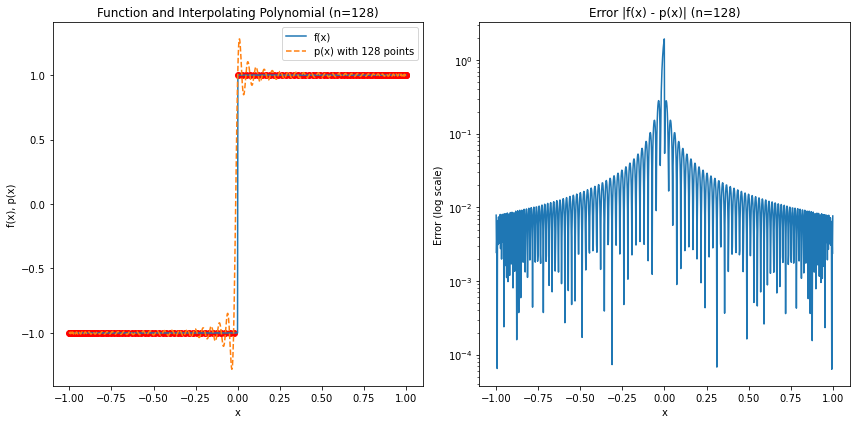

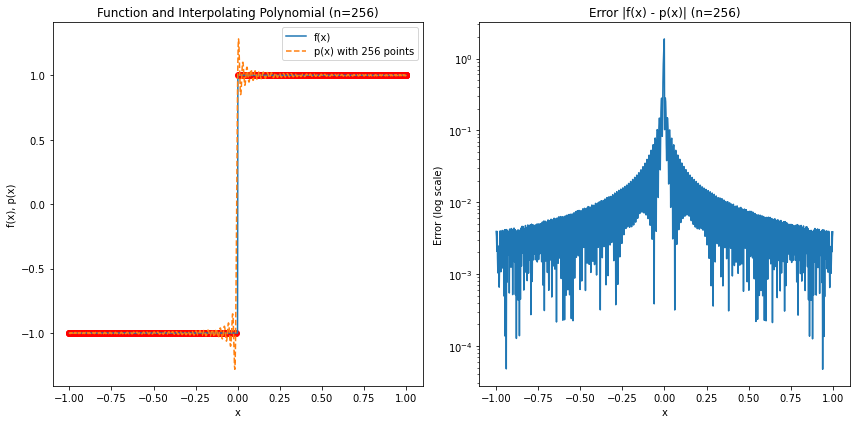

In [13]:
# Plot for different numbers of points: 128,256
for n_points in [128, 256]:
    plot_approximation_and_error(n_points)
